**Import Libraries**

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( accuracy_score, confusion_matrix, classification_report)
from sklearn.impute import SimpleImputer


**Load Dataset**

In [32]:
df = pd.read_csv("/content/heart_disease_uci.csv")

**Exploratory Data Analysis**

In [33]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


**Data preprocessing**

In [34]:
df["target"] = (df["num"] > 0).astype(int)

In [35]:
df = df.drop(columns = ["dataset", "ca", "thal", "slope"])

In [36]:
x = df.drop(columns = ["target", "num"])
y = df["target"]

**Train Test Split**

In [37]:
x_train, x_test, y_train, y_test  = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

In [38]:
numeric_feature = x.select_dtypes(include = ["int64", "float64"]).columns.tolist()
print(numeric_feature)

['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak']


**Build the Numerical Pipeline**

In [39]:
numeric_transformer = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy ='median')),
    ("scaler",  StandardScaler())
])

**Identify Categorical Features**

In [40]:
categorical_feature = x.select_dtypes(include = ["object"]).columns.tolist()
print(categorical_feature)

['sex', 'cp', 'fbs', 'restecg', 'exang']


**Build the Categorical Pipeline**

In [41]:
categorical_transformer = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown = "ignore"))
]
)

**Create the ColumnTransformer**

In [42]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", numeric_transformer, numeric_feature),
        ("cat", categorical_transformer, categorical_feature)
    ]
)

In [43]:
model = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter = 1000))
    ]
)

In [44]:
model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['id', 'age', 'trestbps',
                                                   'chol', 'thalch',
                                                   'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

**Model Evaluation**

In [45]:
y_pred = model.predict(x_test)

In [47]:
print(f"Actual Value = {y_test.values[:10]}")
print(f"Predicted value = {y_pred[:10]}")

Actual Value = [1 1 1 1 0 0 0 1 0 1]
Predicted value = [1 1 1 1 1 1 1 1 0 1]


In [48]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy = {accuracy}")

Accuracy = 0.8369565217391305


In [49]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[61 21]
 [ 9 93]]


In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.74      0.80        82
           1       0.82      0.91      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



In [52]:
from sklearn.metrics import ConfusionMatrixDisplay

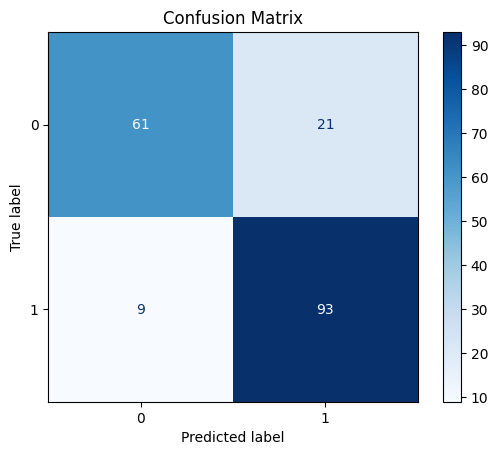

In [53]:
ConfusionMatrixDisplay.from_predictions( y_test, y_pred, cmap = "Blues")
plt.title("Confusion Matrix")
plt.show()

**Predict On New Data**

In [54]:
new_patient = pd.DataFrame({
    "id": [921],
    "age": [55],
    "sex": ["Male"],
    "cp": ["asymptomatic"],
    "trestbps": [140],
    "chol": [250],
    "fbs": ["false"],
    "restecg": ["normal"],
    "thalch": [150],
    "exang": ["false"],
    "oldpeak": [1.5]
})

In [56]:
prediction = model.predict(new_patient)
print(prediction)

[1]


In [57]:
y_prob = model.predict_proba(x_test)

In [58]:
model.predict(x_test[:5])

array([1, 1, 1, 1, 1])

In [59]:
print(y_prob[:5])

[[0.49608266 0.50391734]
 [0.01821404 0.98178596]
 [0.05761816 0.94238184]
 [0.01233638 0.98766362]
 [0.23227252 0.76772748]]


In [60]:
for i in range (5):
  print(f"Patient = {i+1}")
  print(f"Actual Value = {y_test.iloc[i]}")
  print(f"prediction = {y_pred[i]}")
  print(f"Probability = {y_prob[i]}")
  print("-"* 40)

Patient = 1
Actual Value = 1
prediction = 1
Probability = [0.49608266 0.50391734]
----------------------------------------
Patient = 2
Actual Value = 1
prediction = 1
Probability = [0.01821404 0.98178596]
----------------------------------------
Patient = 3
Actual Value = 1
prediction = 1
Probability = [0.05761816 0.94238184]
----------------------------------------
Patient = 4
Actual Value = 1
prediction = 1
Probability = [0.01233638 0.98766362]
----------------------------------------
Patient = 5
Actual Value = 0
prediction = 1
Probability = [0.23227252 0.76772748]
----------------------------------------


**Save Model**

In [61]:
!pip install joblib

In [63]:
import joblib

joblib.dump(model, "heart_disease_model.pkl")

print("Model saved successfully!")


Model saved successfully!


In [64]:
loaded_model = joblib.load("heart_disease_model.pkl")

# Conclusion

In this project, I built a Heart Disease Prediction model using Logistic Regression.

I performed data preprocessing, handled missing values, encoded categorical features, built a machine learning pipeline, trained the model, and evaluated its performance.

The model achieved an accuracy of approximately 83% on the test dataset.